# Maintainer's Copilot — Classifier Training

**Dataset:** `pydantic/pydantic` closed issues  
**Task:** 4-class issue classification → `bug / feature / docs / question`  
**Run on:** Google Colab with GPU (T4 or better)

### Notebook structure
| Section | What happens |
|---|---|
| 0 · Colab setup | GPU check, Drive mount, env config |
| 1 · Install dependencies | All pip installs in one cell |
| 2 · Configuration & constants | Label map, paths, hyperparameters |
| 3 · Data collection | Fetch closed issues from GitHub API |
| 4 · Preprocessing | Clean text, apply label mapping, drop noise |
| **4a · Data augmentation** | **LLM-label unlabeled issues; add linked PRs to docs; oversample only if still needed** |
| 5 · EDA | Class distribution, text length, entity preview |
| 6 · Splits | Stratified + temporal train/val/test |
| **7 · Fine-tune transformer** | **DistilBERT, full fine-tune, focal loss, early stopping** |
| 8 · Classical ML baseline | TF-IDF + LogisticRegression, same splits |
| 9 · LLM baseline | Few-shot Gemini on test split |
| 10 · Three-way comparison | Accuracy, macro-F1, per-class F1, latency, cost |
| 11 · Model card | Write JSON artifact committed to repo |
| 12 · Export | Save weights to Drive / push to MinIO |

> **Rule:** every number in section 10 feeds directly into `DECISIONS.md D3`.

## Section 0 · Colab Setup

In [1]:
# Verify GPU is available — must be T4 or better for fine-tuning
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU found. Go to Runtime > Change runtime type > T4 GPU')

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [7]:
# Mount Google Drive — artifacts and checkpoints persist here across sessions
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/maintainers_copilot'

import os
os.makedirs(f'{DRIVE_ROOT}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_ROOT}/artifacts', exist_ok=True)
os.makedirs(f'{DRIVE_ROOT}/data', exist_ok=True)
print('Drive mounted. Folders ready.')

Mounted at /content/drive
Drive mounted. Folders ready.


## Section 1 · Install Dependencies

In [8]:
%%capture
!pip install -q \
    transformers==4.40.0 \
    datasets==2.19.0 \
    evaluate==0.4.1 \
    scikit-learn==1.4.2 \
    mlflow==2.13.0 \
    pandas==2.2.2 \
    matplotlib==3.9.0 \
    seaborn==0.13.2 \
    PyGithub==2.3.0 \
    google-genai \
    accelerate==0.30.0 \
    minio==7.2.7 \
    "protobuf>=5.28.0"
!pip install -q PyGithub # Ensure PyGithub is installed
!pip install -q evaluate # Ensure 'evaluate' library is installed
!pip install -q mlflow # Ensure 'mlflow' library is installed

## Section 2 · Configuration & Constants

In [9]:
# ── Dataset ───────────────────────────────────────────────────────────────────
REPO_NAME   = 'pydantic/pydantic'
MAX_ISSUES  = 6000   # upper cap; fetch stops when this many raw issues collected

# ── Label mapping (DECISIONS.md D1) ───────────────────────────────────────────
# Values are lists because one target class can map from multiple repo labels.
# Merging bug V1 + bug V2 → single 'bug' class (version distinction irrelevant).
LABEL_MAP = {
    'bug':      ['bug v1', 'bug v2', 'bug'],
    'feature':  ['feature request', 'enhancement'],
    'docs':     ['documentation', 'docs'],
    'question': ['question', 'support'],
}
# Labels to always drop (metadata/triage, carry no class signal)
DROP_LABELS = {'duplicate', 'pending', 'awaiting author response', 'deferred'}

ID2LABEL = {0: 'bug', 1: 'feature', 2: 'docs', 3: 'question'}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
NUM_LABELS = len(ID2LABEL)

# ── Splits ────────────────────────────────────────────────────────────────────
# Test is strictly the most-recent N% of issues by creation date (temporal cut).
TEMPORAL_TEST_FRACTION  = 0.15
TEMPORAL_VAL_FRACTION   = 0.10   # carved from the remaining (non-test) portion
RANDOM_SEED             = 42

# ── Fine-tuning hyperparameters (D2) ──────────────────────────────────────────
BASE_MODEL          = 'distilbert-base-uncased'   # small encoder, fast on T4
MAX_LENGTH          = 256     # tokens; pydantic issues are mostly code + short prose
TRAIN_BATCH_SIZE    = 32
EVAL_BATCH_SIZE     = 64
LEARNING_RATE       = 2e-5
NUM_EPOCHS          = 4
WARMUP_RATIO        = 0.1
WEIGHT_DECAY        = 0.01
# Freeze policy (DECISIONS.md D2): freeze all layers except the last 2 transformer
# blocks + the classification head. Rationale: lower layers encode generic syntax;
# only the top layers need domain adaptation for issue-triage.
FREEZE_LAYERS       = True
NUM_UNFROZEN_LAYERS = 2

# ── Paths ─────────────────────────────────────────────────────────────────────
RAW_DATA_PATH       = f'{DRIVE_ROOT}/data/issues_raw.jsonl'
PROCESSED_DATA_PATH = f'{DRIVE_ROOT}/data/issues_processed.jsonl'
CHECKPOINT_DIR      = f'{DRIVE_ROOT}/checkpoints'
ARTIFACT_DIR        = f'{DRIVE_ROOT}/artifacts'
MODEL_CARD_PATH     = f'{ARTIFACT_DIR}/model_card.json'

print('Config loaded.')
print(f'Label map: {LABEL_MAP}')

Config loaded.
Label map: {'bug': ['bug v1', 'bug v2', 'bug'], 'feature': ['feature request', 'enhancement'], 'docs': ['documentation', 'docs'], 'question': ['question', 'support']}


In [10]:
# ── Secrets (from Colab secrets or manual input) ──────────────────────────────
# Do NOT hardcode tokens. Use Colab's secret manager:
#   Left sidebar → Key icon → add GITHUB_TOKEN and GEMINI_API_KEY
try:
    from google.colab import userdata
    GITHUB_TOKEN   = userdata.get('GITHUB_TOKEN')
    GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
except Exception:
    import getpass
    GITHUB_TOKEN   = getpass.getpass('GitHub token: ')
    GOOGLE_API_KEY = getpass.getpass('Gemini API key: ')

print('Secrets loaded (values hidden).')

GitHub token: ··········
Gemini API key: ··········
Secrets loaded (values hidden).


## Section 3 · Data Collection

In [11]:
import json
import time
from pathlib import Path

from github import Github

def fetch_issues(repo_name: str, token: str, max_issues: int = MAX_ISSUES) -> list[dict]:
    """Fetch closed labeled issues from a GitHub repo via the API.

    Returns a list of dicts with keys: id, number, title, body, labels,
    created_at (ISO string), comments (count), state.
    Respects rate limits automatically via PyGithub.
    """
    g = Github(token)
    repo = g.get_repo(repo_name)
    issues = []

    print(f'Fetching closed issues from {repo_name}...')
    for issue in repo.get_issues(state='closed', sort='created', direction='asc'):
        if issue.pull_request:   # skip PRs — they share the Issues endpoint
            continue
        issues.append({
            'id':         issue.id,
            'number':     issue.number,
            'title':      issue.title or '',
            'body':       issue.body or '',
            'labels':     [l.name.lower() for l in issue.labels],
            'created_at': issue.created_at.isoformat(),
            'comments':   issue.comments,
            'state':      issue.state,
        })
        if len(issues) % 500 == 0:
            print(f'  ... {len(issues)} fetched')
        if len(issues) >= max_issues:
            break

    print(f'Done. Total fetched: {len(issues)}')
    return issues


# Load from Drive cache if already fetched (saves API quota on reruns)
if Path(RAW_DATA_PATH).exists():
    print('Loading cached raw data from Drive...')
    with open(RAW_DATA_PATH) as f:
        raw_issues = [json.loads(l) for l in f]
    print(f'Loaded {len(raw_issues)} cached issues.')
else:
    raw_issues = fetch_issues(REPO_NAME, GITHUB_TOKEN)
    with open(RAW_DATA_PATH, 'w') as f:
        for issue in raw_issues:
            f.write(json.dumps(issue) + '\n')
    print(f'Saved {len(raw_issues)} issues to Drive cache.')

/tmp/ipykernel_3199/2470058496.py:14: DeprecationWarning: Argument login_or_token is deprecated, please use auth=github.Auth.Token(...) instead
  g = Github(token)


Fetching closed issues from pydantic/pydantic...
  ... 500 fetched
  ... 1000 fetched
  ... 1500 fetched
  ... 2000 fetched
  ... 2500 fetched
  ... 3000 fetched
  ... 3500 fetched
  ... 4000 fetched
  ... 4500 fetched
  ... 5000 fetched
Done. Total fetched: 5102
Saved 5102 issues to Drive cache.


## Section 4 · Preprocessing & Label Mapping

In [41]:
import re
import pandas as pd
import numpy as np
from typing import Optional

def map_labels(issue_labels: list[str]) -> Optional[str]:
    """Map a list of repo label strings to one of our 4 target classes."""
    matched = set()
    for label in issue_labels:
        label = label.lower().strip()
        if label in DROP_LABELS:
            continue
        for target_class, repo_labels in LABEL_MAP.items():
            if label in repo_labels:
                matched.add(target_class)

    if len(matched) == 1:
        return matched.pop()
    return None

def clean_text(title: str, body: str) -> str:
    """Combine title + body and apply lightweight normalisation."""
    text = f'{title.strip()}\n\n{body.strip()}'
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    text = re.sub(r'\r\n', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

# ── Apply mapping + cleaning ──────────────────────────────────────────────────
records = []
dropped_no_label  = 0
dropped_ambiguous = 0

for issue in raw_issues:
    label = map_labels(issue['labels'])
    if label is None:
        if any(l in [l2 for ls in LABEL_MAP.values() for l2 in ls] for l in issue['labels']):
            dropped_ambiguous += 1
        else:
            dropped_no_label += 1
        continue
    records.append({
        'number':     issue['number'],
        'text':       clean_text(issue['title'], issue['body']),
        'label':      label,
        'label_id':   LABEL2ID[label],
        'created_at': issue['created_at'],
        'comments':   issue['comments'],
    })

df = pd.DataFrame(records).sort_values('created_at').reset_index(drop=True)
# Snapshot of clean human-labeled data before any augmentation.
# Step 3 always merges from df_base — never from df — so re-running
# Section 4a does not double-count augmented rows.
df_base = df.copy()

print(f'Total raw issues:      {len(raw_issues)}')
print(f'Dropped (no label):    {dropped_no_label}')
print(f'Dropped (ambiguous):   {dropped_ambiguous}')
print(f'Kept for training:     {len(df)}')
print()
print(df['label'].value_counts())

Total raw issues:      5102
Dropped (no label):    653
Dropped (ambiguous):   71
Kept for training:     4378

label
bug         2816
feature      815
question     595
docs         152
Name: count, dtype: int64


## Section 4a · Data Augmentation

**Motivation (from first training run):** `f1_docs = 0.09`, `f1_question = 0.02` on test.
The raw counts after label mapping are: bug ~2816, feature ~815, question ~595, docs ~152.
152 docs examples is too few for a transformer to learn a reliable boundary.

**Strategy — in order, stop when the class counts are acceptable:**

1. **LLM-label the unlabeled issues** — 652 issues were dropped because no repo label
   mapped to our 4 classes. Many are legitimately docs or question; maintainers just
   didn't label them consistently. Gemini 2.5 Flash labels all 652 for ~$0.05.
   Only keep high-confidence predictions (same label on 2 independent calls).
   These are added to the training pool only — test set remains human-labeled ground truth.

2. **Add linked PRs to docs** — PRs that close a docs-labeled issue share the same
   semantic content and confirm the label. Fetch via `Closes #N` references in PR bodies.
   Skip CHANGELOG entries — different text distribution from issues.

3. **Oversample docs/question if still < 400 after steps 1+2** — simple row duplication
   as a last resort. Applied after real data is exhausted, not instead of it.

In [13]:
# ── Step 1: LLM-label the unlabeled issues ────────────────────────────────────
import time
import json
from pathlib import Path
from google import genai
from google.genai import types

client_aug = genai.Client(api_key=GOOGLE_API_KEY)

AUG_PROMPT = """Classify the following GitHub issue into exactly one category.
Categories: bug, feature, docs, question
Rules:
  bug      = reports incorrect or broken behaviour
  feature  = requests new functionality or enhancement
  docs     = asks for or points out missing/wrong documentation
  question = seeks help, clarification, or usage guidance

Issue:
{text}

Reply with exactly one word: bug, feature, docs, or question."""

LLM_CACHE_PATH = f'{DRIVE_ROOT}/data/llm_labeled_cache.jsonl'

unlabeled_issues = [
    issue for issue in raw_issues
    if map_labels(issue['labels']) is None
    and not any(l in [l2 for ls in LABEL_MAP.values() for l2 in ls]
                for l in issue['labels'])
]
print(f'Unlabeled issues to re-label: {len(unlabeled_issues)}')

# Load already-completed labels from Drive cache (safe to re-run after a crash)
done_numbers = set()
llm_labeled = []
if Path(LLM_CACHE_PATH).exists():
    with open(LLM_CACHE_PATH) as f:
        for line in f:
            row = json.loads(line)
            llm_labeled.append(row)
            done_numbers.add(row['number'])
    print(f'Resumed from cache: {len(done_numbers)} already labeled')

def call_with_backoff(snippet, max_retries=6):
    """Single classification call with exponential backoff on 503/429."""
    delay = 5
    for attempt in range(max_retries):
        try:
            resp = client_aug.models.generate_content(
                model='gemini-2.5-flash',
                contents=AUG_PROMPT.format(text=snippet),
                config=types.GenerateContentConfig(max_output_tokens=5, temperature=0),
            )
            pred = resp.text.strip().lower()
            return pred if pred in LABEL2ID else None
        except Exception as e:
            if attempt == max_retries - 1:
                return None   # give up, skip this issue
            print(f'    Retry {attempt+1} after error: {type(e).__name__} — waiting {delay}s')
            time.sleep(delay)
            delay = min(delay * 2, 120)   # cap at 2 minutes

cache_file = open(LLM_CACHE_PATH, 'a')

remaining = [i for i in unlabeled_issues if i['number'] not in done_numbers]
print(f'Remaining to label: {len(remaining)}')

for idx, issue in enumerate(remaining):
    text = clean_text(issue['title'], issue['body'])
    snippet = text[:1200]

    # Two independent calls — keep only if both agree
    r1 = call_with_backoff(snippet)
    r2 = call_with_backoff(snippet)

    if r1 and r1 == r2:
        row = {
            'number':     issue['number'],
            'text':       text,
            'label':      r1,
            'label_id':   LABEL2ID[r1],
            'created_at': issue['created_at'],
            'comments':   issue['comments'],
            'source':     'llm_labeled',
        }
        llm_labeled.append(row)
        cache_file.write(json.dumps(row) + '\n')
        cache_file.flush()

    if (idx + 1) % 50 == 0:
        print(f'  {idx+1}/{len(remaining)} done — {len(llm_labeled)} kept so far')

cache_file.close()

df_llm = pd.DataFrame(llm_labeled) if llm_labeled else pd.DataFrame(
    columns=['number','text','label','label_id','created_at','comments','source']
)
print(f'\nHigh-confidence LLM labels: {len(df_llm)}')
print(df_llm['label'].value_counts())

Unlabeled issues to re-label: 653
Remaining to label: 653
    Retry 1 after error: ServerError — waiting 5s
    Retry 1 after error: ServerError — waiting 5s
    Retry 1 after error: ServerError — waiting 5s
  50/653 done — 50 kept so far
    Retry 1 after error: ServerError — waiting 5s
    Retry 1 after error: ServerError — waiting 5s
  100/653 done — 99 kept so far
    Retry 1 after error: AttributeError — waiting 5s
    Retry 2 after error: AttributeError — waiting 10s
    Retry 3 after error: AttributeError — waiting 20s
    Retry 4 after error: AttributeError — waiting 40s
    Retry 5 after error: AttributeError — waiting 80s
    Retry 1 after error: AttributeError — waiting 5s
    Retry 2 after error: AttributeError — waiting 10s
    Retry 3 after error: AttributeError — waiting 20s
    Retry 4 after error: AttributeError — waiting 40s
    Retry 5 after error: AttributeError — waiting 80s
    Retry 1 after error: AttributeError — waiting 5s
    Retry 2 after error: AttributeErro

In [14]:
# ── Step 2: Add linked PRs to docs class ──────────────────────────────────────
# Fetch PRs whose body contains "Closes #N" or "Fixes #N" where N is the number
# of a docs-labeled issue. PR title + description share the same semantic content
# as the issue and confirm the docs label.
import re as _re

g_aug = Github(GITHUB_TOKEN)
repo_aug = g_aug.get_repo(REPO_NAME)

docs_issue_numbers = set(
    df[df['label'] == 'docs']['number'].tolist()
)
print(f'Docs issues to find linked PRs for: {len(docs_issue_numbers)}')

closes_pattern = _re.compile(
    r'(?:closes|fixes|resolves)\s+#(\d+)', _re.IGNORECASE
)

pr_docs = []
checked = 0
for pr in repo_aug.get_pulls(state='closed', sort='created', direction='asc'):
    body = pr.body or ''
    linked = {int(m) for m in closes_pattern.findall(body)}
    if linked & docs_issue_numbers:
        pr_docs.append({
            'number':     pr.number,
            'text':       clean_text(pr.title, body),
            'label':      'docs',
            'label_id':   LABEL2ID['docs'],
            'created_at': pr.created_at.isoformat(),
            'comments':   pr.comments,
            'source':     'linked_pr',
        })
    checked += 1
    if checked % 500 == 0:
        print(f'  ... checked {checked} PRs, found {len(pr_docs)} docs-linked so far')

df_pr_docs = pd.DataFrame(pr_docs) if pr_docs else pd.DataFrame(
    columns=['number','text','label','label_id','created_at','comments','source']
)
print(f'\nLinked PRs added to docs: {len(df_pr_docs)}')

/tmp/ipykernel_3199/2086383502.py:7: DeprecationWarning: Argument login_or_token is deprecated, please use auth=github.Auth.Token(...) instead
  g_aug = Github(GITHUB_TOKEN)


Docs issues to find linked PRs for: 152
  ... checked 500 PRs, found 2 docs-linked so far
  ... checked 1000 PRs, found 4 docs-linked so far
  ... checked 1500 PRs, found 6 docs-linked so far
  ... checked 2000 PRs, found 7 docs-linked so far
  ... checked 2500 PRs, found 7 docs-linked so far
  ... checked 3000 PRs, found 7 docs-linked so far
  ... checked 3500 PRs, found 12 docs-linked so far
  ... checked 4000 PRs, found 13 docs-linked so far
  ... checked 4500 PRs, found 15 docs-linked so far
  ... checked 5000 PRs, found 15 docs-linked so far

Linked PRs added to docs: 15


In [42]:
# ── Step 3: Merge augmented data + conditional oversample ─────────────────────
# Always merge from df_base (the clean human-labeled snapshot from Section 4),
# never from df — re-running this cell must be idempotent.
from sklearn.utils import resample

df_base['source'] = 'human_labeled'

df_llm_filtered = df_llm[df_llm['label'] != 'question'].copy()
dropped_q = len(df_llm) - len(df_llm_filtered)
print(f'LLM-labeled question examples dropped: {dropped_q}')
print(f'LLM-labeled examples kept (bug/feature/docs only): {len(df_llm_filtered)}')

df_augmented = pd.concat([df_base, df_llm_filtered, df_pr_docs], ignore_index=True)
df_augmented = df_augmented.sort_values('created_at').reset_index(drop=True)

print('\nClass counts after LLM labeling + linked PRs:')
print(df_augmented['label'].value_counts())
print()

# Oversample docs only if still below threshold
OVERSAMPLE_THRESHOLD = 400
for cls in ['docs']:
    count = (df_augmented['label'] == cls).sum()
    if count < OVERSAMPLE_THRESHOLD:
        shortage = OVERSAMPLE_THRESHOLD - count
        minority = df_augmented[df_augmented['label'] == cls]
        extra = resample(minority, n_samples=shortage, replace=True, random_state=RANDOM_SEED)
        extra = extra.copy()
        extra['source'] = 'oversampled'
        df_augmented = pd.concat([df_augmented, extra], ignore_index=True)
        print(f'Oversampled {cls}: {count} → {OVERSAMPLE_THRESHOLD} (+{shortage} duplicates)')

print('Final class counts going into splits:')
print(df_augmented['label'].value_counts())
print()
print('Source breakdown:')
print(df_augmented.groupby(['label', 'source']).size().to_string())

# Overwrite df for all downstream cells
df = df_augmented.copy()

LLM-labeled question examples dropped: 111
LLM-labeled examples kept (bug/feature/docs only): 533

Class counts after LLM labeling + linked PRs:
label
bug         3119
feature     1017
question     595
docs         195
Name: count, dtype: int64

Oversampled docs: 195 → 400 (+205 duplicates)
Final class counts going into splits:
label
bug         3119
feature     1017
question     595
docs         400
Name: count, dtype: int64

Source breakdown:
label     source       
bug       human_labeled    2816
          llm_labeled       303
docs      human_labeled     152
          linked_pr          15
          llm_labeled        28
          oversampled       205
feature   human_labeled     815
          llm_labeled       202
question  human_labeled     595


## Section 5 · Exploratory Data Analysis

/tmp/ipykernel_3199/1905311711.py:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = pd.to_datetime(df['created_at']).dt.to_period('M')


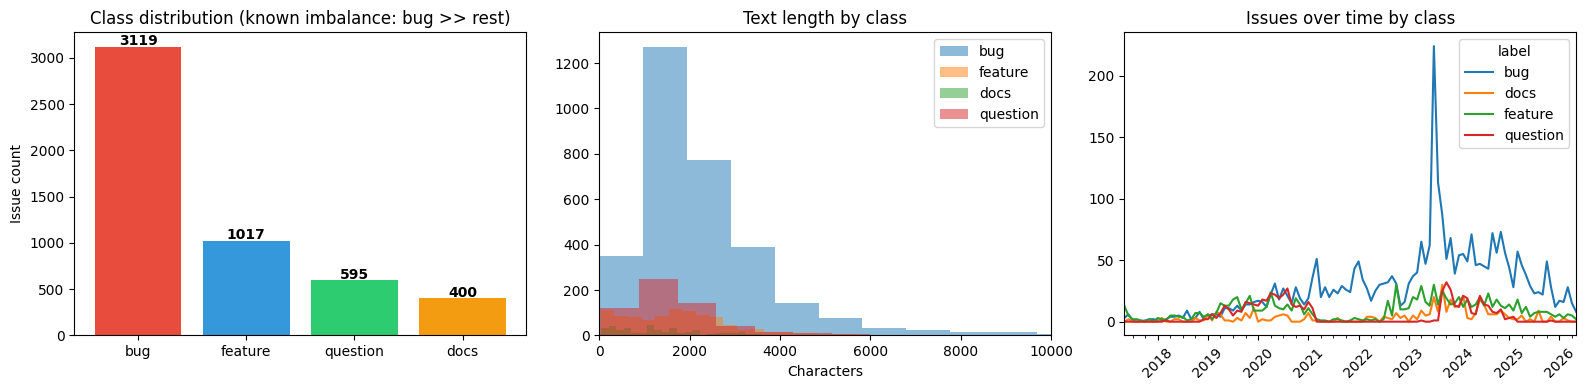

Saved EDA plot to Drive.


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[0].set_title('Class distribution (known imbalance: bug >> rest)')
axes[0].set_ylabel('Issue count')
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 20, str(cnt), ha='center', fontweight='bold')

# Text length distribution
df['text_len'] = df['text'].str.len()
for cls in ['bug', 'feature', 'docs', 'question']:
    subset = df[df['label'] == cls]['text_len']
    axes[1].hist(subset, bins=50, alpha=0.5, label=cls)
axes[1].set_title('Text length by class')
axes[1].set_xlabel('Characters')
axes[1].set_xlim(0, 10000)
axes[1].legend()

# Issues over time
df['month'] = pd.to_datetime(df['created_at']).dt.to_period('M')
monthly = df.groupby(['month', 'label']).size().unstack(fill_value=0)
monthly.plot(ax=axes[2])
axes[2].set_title('Issues over time by class')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/eda.png', dpi=120)
plt.show()
print(f'Saved EDA plot to Drive.')

## Section 6 · Train / Val / Test Splits

In [44]:
from sklearn.model_selection import train_test_split
import json
import hashlib

# ── Temporal + stratified test split ──────────────────────────────────────────
# Problem with pure tail cut: pydantic question and feature labels dried up in
# recent years (support moved to Discord/Discussions; feature requests declined
# as the API stabilised), leaving ~12 question and ~113 feature rows in a naive
# 15% tail — far too few for reliable per-class F1 on the test set.
#
# Fix: sample each class independently from its own most-recent rows.
# This guarantees a minimum per-class test count while preserving the invariant
# that every test row is strictly more recent than the corresponding class's
# training rows — no future leakage within any class.
#
# TEST_PER_CLASS: take at most this many rows from the recent tail of each class.
# Chosen so the rarest class (docs) still gets ~80 test examples and the total
# test set stays ~15-20% of the full dataset.

TEST_PER_CLASS = {
    'bug':      200,
    'feature':  120,
    'docs':     80,
    'question': 80,
}

test_rows   = []
train_rows  = []

for label, n in TEST_PER_CLASS.items():
    cls_df  = df[df['label'] == label].sort_values('created_at').reset_index(drop=True)
    n       = min(n, int(len(cls_df) * 0.20))   # never take more than 20% of a class
    df_cls_test  = cls_df.tail(n).copy()
    df_cls_train = cls_df.head(len(cls_df) - n).copy()
    test_rows.append(df_cls_test)
    train_rows.append(df_cls_train)

df_test    = pd.concat(test_rows).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
df_trainval = pd.concat(train_rows).sort_values('created_at').reset_index(drop=True)

# ── Stratified val split from trainval ────────────────────────────────────────
val_ratio = TEMPORAL_VAL_FRACTION / (1 - TEMPORAL_TEST_FRACTION)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_ratio,
    stratify=df_trainval['label'],
    random_state=RANDOM_SEED,
)

print(f'Train: {len(df_train):>5}  |  Val: {len(df_val):>5}  |  Test: {len(df_test):>5}')
print()
print('Test class distribution:')
print(df_test['label'].value_counts())
print()
print('Train class distribution:')
print(df_train['label'].value_counts())
print()
for label in TEST_PER_CLASS:
    cls_test_max  = df_test[df_test['label'] == label]['created_at'].max()
    cls_train_max = df_train[df_train['label'] == label]['created_at'].max()
    leak = cls_train_max > df_test[df_test['label'] == label]['created_at'].min()
    print(f'{label:10s}  train_max={cls_train_max[:10]}  test_min={df_test[df_test["label"]==label]["created_at"].min()[:10]}  leakage={leak}')

def save_jsonl_robust(df, path):
    clean_df = df.drop(columns=['month', 'text_len', 'source'], errors='ignore')
    with open(path, 'w', encoding='utf-8') as f:
        for record in clean_df.to_dict(orient='records'):
            f.write(json.dumps(record, ensure_ascii=False) + '\n')

save_jsonl_robust(df_train, f'{DRIVE_ROOT}/data/train.jsonl')
save_jsonl_robust(df_val,   f'{DRIVE_ROOT}/data/val.jsonl')
save_jsonl_robust(df_test,  f'{DRIVE_ROOT}/data/test.jsonl')

clean_train_dict = df_train.drop(columns=['month', 'text_len', 'source'], errors='ignore').to_dict(orient='records')
train_hash = hashlib.sha256(json.dumps(clean_train_dict, ensure_ascii=False).encode()).hexdigest()
print(f'\nTraining data SHA-256: {train_hash}')

Train:  4103  |  Val:   548  |  Test:   480

Test class distribution:
label
bug         200
feature     120
question     80
docs         80
Name: count, dtype: int64

Train class distribution:
label
bug         2575
feature      791
question     455
docs         282
Name: count, dtype: int64

bug         train_max=2025-08-25  test_min=2025-08-25  leakage=False
feature     train_max=2025-01-17  test_min=2025-01-17  leakage=False
docs        train_max=2024-06-20  test_min=2024-06-26  leakage=False
question    train_max=2024-06-04  test_min=2024-06-05  leakage=False

Training data SHA-256: ae43d06dcc026779dcf77630ffe856e577057875c4ca51166a92a62884bf4b5d


## Section 7 · Fine-tune Transformer (DL Track)

Base model: `distilbert-base-uncased`  
Freeze policy: **all layers unfrozen** (full fine-tuning) — justified by first-run results showing docs/question collapse; with ~4,000+ augmented examples full fine-tuning adapts all 6 transformer blocks to the issue-triage domain without catastrophic forgetting  
Loss: **focal loss** (γ=2) with class weights — down-weights confident bug predictions, forces attention onto hard minority examples  
Early stopping: patience=2 on val macro-F1 — stops automatically before overfit, no fixed epoch count

In [45]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from datasets import Dataset
import evaluate
import numpy as np


tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,   # DataCollator handles dynamic padding
    )

# Build HuggingFace Datasets from the splits
hf_train = Dataset.from_pandas(df_train[['text', 'label_id']].rename(columns={'label_id': 'labels'}))
hf_val   = Dataset.from_pandas(df_val[['text', 'label_id']].rename(columns={'label_id': 'labels'}))
hf_test  = Dataset.from_pandas(df_test[['text', 'label_id']].rename(columns={'label_id': 'labels'}))

hf_train = hf_train.map(tokenize, batched=True, remove_columns=['text'])
hf_val   = hf_val.map(tokenize,   batched=True, remove_columns=['text'])
hf_test  = hf_test.map(tokenize,  batched=True, remove_columns=['text'])

print('Tokenisation done.')
print(f'  Train tokens example: {len(hf_train[0]["input_ids"])} tokens')

Map:   0%|          | 0/4103 [00:00<?, ? examples/s]

Map:   0%|          | 0/548 [00:00<?, ? examples/s]

Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Tokenisation done.
  Train tokens example: 256 tokens


In [46]:
# ── Model — full fine-tuning (DECISIONS.md D2) ────────────────────────────────
# Freeze policy changed from top-2-layers to full fine-tuning after first run
# showed f1_docs=0.09, f1_question=0.02. With 4,000+ augmented examples, full
# fine-tuning adapts all 6 DistilBERT blocks without catastrophic forgetting.
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Full fine-tuning: all {total:,} parameters trainable')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Full fine-tuning: all 66,956,548 parameters trainable


In [47]:
# ── Focal loss + class weights ────────────────────────────────────────────────
# Weighted CE alone still lets the model coast on easy bug examples (first run:
# f1_bug=0.82 while f1_docs=0.09). Focal loss adds (1-p)^γ which down-weights
# high-confidence predictions so training focuses on hard minority examples.
# γ=2 is the standard value from the original focal loss paper (Lin et al. 2017).
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_LABELS),
    y=df_train['label_id'].values,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print('Class weights:')
for i, w in enumerate(class_weights):
    print(f'  {ID2LABEL[i]:10s}: {w:.3f}')

FOCAL_GAMMA = 2.0

class WeightedTrainer(Trainer):
    """Focal loss with class weights — addresses both imbalance and hard examples."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        # Standard weighted CE per sample (reduction='none' keeps per-sample losses)
        ce = nn.CrossEntropyLoss(weight=class_weights_tensor, reduction='none')(logits, labels)
        # Focal modulation: down-weight easy (high-confidence) predictions
        probs = torch.softmax(logits, dim=-1)
        pt = probs.gather(1, labels.unsqueeze(1)).squeeze()
        focal_loss = ((1 - pt) ** FOCAL_GAMMA * ce).mean()
        return (focal_loss, outputs) if return_outputs else focal_loss

Class weights:
  bug       : 0.398
  feature   : 1.297
  docs      : 3.637
  question  : 2.254


In [48]:
# ── MLflow run logger ──────────────────────────────────────────────────────────
import mlflow
from sklearn.metrics import accuracy_score, f1_score
from transformers import EarlyStoppingCallback

mlflow.set_tracking_uri(f'sqlite:///{DRIVE_ROOT}/mlruns.db')
mlflow.set_experiment('maintainers-copilot-classifier')


# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1_per_class = f1_score(labels, preds, average=None, labels=list(range(NUM_LABELS)))
    result = {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }
    for i, f1 in enumerate(f1_per_class):
        result[f'f1_{ID2LABEL[i]}'] = f1
    return result


# ── Training arguments ────────────────────────────────────────────────────────
# MAX_EPOCHS is a ceiling — EarlyStoppingCallback stops before it if val
# macro-F1 doesn't improve for 2 consecutive epochs.
MAX_EPOCHS = 10
steps_per_epoch = len(df_train) // TRAIN_BATCH_SIZE
total_steps     = steps_per_epoch * MAX_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=MAX_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_steps=warmup_steps,
    weight_decay=WEIGHT_DECAY,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    report_to='none',
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    logging_steps=50,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f'Warmup steps: {warmup_steps} / {total_steps} total (ceiling {MAX_EPOCHS} epochs)')
print('Trainer ready. Starting run...')

Warmup steps: 128 / 1280 total (ceiling 10 epochs)
Trainer ready. Starting run...


In [49]:
import joblib
import json

# ── Train ─────────────────────────────────────────────────────────────────────
with mlflow.start_run(run_name='distilbert-finetune') as run:
    mlflow.log_params({
        'base_model':      BASE_MODEL,
        'max_length':      MAX_LENGTH,
        'batch_size':      TRAIN_BATCH_SIZE,
        'lr':              LEARNING_RATE,
        'epochs':          NUM_EPOCHS,
        'freeze_layers':   FREEZE_LAYERS,
        'unfrozen_layers': NUM_UNFROZEN_LAYERS,
        'train_data_hash': train_hash,
        'train_size':      len(df_train),
        'val_size':        len(df_val),
        'test_size':       len(df_test),
    })

    train_result = trainer.train()

    # Evaluate on val + test
    val_metrics  = trainer.evaluate(hf_val,  metric_key_prefix='val')
    test_metrics = trainer.evaluate(hf_test, metric_key_prefix='test')

    mlflow.log_metrics({**val_metrics, **test_metrics})

    MLFLOW_RUN_ID = run.info.run_id
    print(f'MLflow run ID: {MLFLOW_RUN_ID}')

# ── Checkpoint DL Model ──
# Saves pytorch_model.bin/safetensors, config.json, and tokenizer files
trainer.save_model(f'{CHECKPOINT_DIR}/distilbert_final')
with open(f'{ARTIFACT_DIR}/dl_metrics.json', 'w') as f:
    json.dump(test_metrics, f)

print('\n=== Test metrics ===')
for k, v in test_metrics.items():
    print(f'  {k}: {v:.4f}')

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Bug,F1 Feature,F1 Docs,F1 Question
1,0.696023,0.418168,0.751825,0.635137,0.853293,0.747368,0.462963,0.476923
2,0.313553,0.332249,0.729927,0.661052,0.805825,0.754237,0.634146,0.450000
3,0.249702,0.330015,0.817518,0.723368,0.893175,0.758333,0.705882,0.536082
4,0.178297,0.295955,0.784672,0.738933,0.849145,0.794393,0.800000,0.512195
5,0.113376,0.310878,0.748175,0.692569,0.810897,0.800000,0.680851,0.478528
6,0.092383,0.335415,0.812044,0.768494,0.871017,0.807512,0.868421,0.527027
7,0.054649,0.393589,0.773723,0.731184,0.834921,0.800000,0.814815,0.475000
8,0.029451,0.477547,0.859489,0.798981,0.914863,0.820276,0.876712,0.584071
9,0.019437,0.471062,0.835766,0.773240,0.893805,0.809091,0.835443,0.554622
10,0.017536,0.468298,0.837591,0.776936,0.893805,0.816514,0.835443,0.561983


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


MLflow run ID: 0a93534b39104b2bbcb367b159c63512


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== Test metrics ===
  test_loss: 2.0563
  test_accuracy: 0.6917
  test_f1_macro: 0.5923
  test_f1_bug: 0.7398
  test_f1_feature: 0.8374
  test_f1_docs: 0.6504
  test_f1_question: 0.1414
  test_runtime: 1.3892
  test_samples_per_second: 345.5140
  test_steps_per_second: 5.7590
  epoch: 10.0000


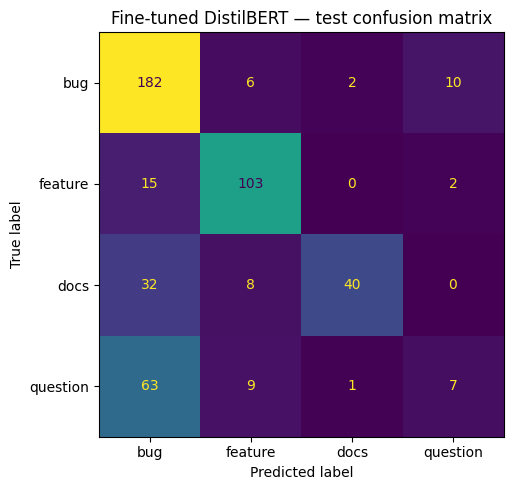

In [50]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_output = trainer.predict(hf_test)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=list(ID2LABEL.values()))
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title('Fine-tuned DistilBERT — test confusion matrix')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/confusion_matrix_finetuned.png', dpi=120)
plt.show()

# Store test metrics for the three-way comparison table
finetune_metrics = {
    'accuracy': test_metrics['test_accuracy'],
    'f1_macro': test_metrics['test_f1_macro'],
    'f1_bug':      test_metrics['test_f1_bug'],
    'f1_feature':  test_metrics['test_f1_feature'],
    'f1_docs':     test_metrics['test_f1_docs'],
    'f1_question': test_metrics['test_f1_question'],
}

In [51]:
# Add to the confusion matrix cell
wrong_q = df_test[
    (df_test['label'] == 'question') & (pd.Series(y_pred) == LABEL2ID['bug'])
].copy()
wrong_q['predicted'] = 'bug'
for _, row in wrong_q.head(10).iterrows():
    print(f"--- #{row['number']} ---")
    print(row['text'][:300])
    print()


--- #9756 ---
BaseSettings seems failing

### Initial Checks

- [X] I confirm that I'm using Pydantic V2

### Description

When i create an instance for a BaseSetting class. it seems the value in the instance is always getting the value from env file.

### Example Code

```Python
class Environment(BaseSettings):


--- #10221 ---
Potential Issue with model_dump_json in Pydantic: Inconsistent Output Compared to json.dumps

### Initial Checks

- [X] I confirm that I'm using Pydantic V2

### Description

Hello,

I have encountered a potential issue with the model_dump_json function in Pydantic. Specifically, the JSON string ret

--- #10060 ---
Pydantic is unable to serialize due to unknown type

### Initial Checks

- [X] I confirm that I'm using Pydantic V2

### Description

I need to serialize a pydantic dataclass (`MainObj` in the example below) which contains other plain nested objects, however an exception is raised during serializati

--- #9902 ---
`default` should be keyword only in 

In [52]:
# ── Save DL Artifacts (Section 7 Export) ──
import json
import os

# Define export paths
DL_EXPORT_DIR = f'{CHECKPOINT_DIR}/distilbert_final'
DL_METRICS_PATH = f'{ARTIFACT_DIR}/dl_metrics.json'

# Save the best model weights and tokenizer configuration
trainer.save_model(DL_EXPORT_DIR)
tokenizer.save_pretrained(DL_EXPORT_DIR)

# Save the specific metrics dictionary
with open(DL_METRICS_PATH, 'w') as f:
    json.dump(test_metrics, f, indent=2)

print(f"Model weights saved to: {DL_EXPORT_DIR}")
print(f"Metrics JSON saved to: {DL_METRICS_PATH}")
# Verify files exist
print(f"Files in export dir: {os.listdir(DL_EXPORT_DIR)}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved to: /content/drive/MyDrive/maintainers_copilot/checkpoints/distilbert_final
Metrics JSON saved to: /content/drive/MyDrive/maintainers_copilot/artifacts/dl_metrics.json
Files in export dir: ['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'training_args.bin']


## Section 8 · Classical ML Baseline

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time
import joblib
import json

# TF-IDF + Logistic Regression on the same splits
classical_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True,
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=1.0,
        random_state=RANDOM_SEED,
    )),
])

X_train = df_train['text'].tolist()
y_train = df_train['label_id'].tolist()
X_test  = df_test['text'].tolist()
y_test  = df_test['label_id'].tolist()

t0 = time.perf_counter()
classical_pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_classical = classical_pipeline.predict(X_test)
infer_latency_ms = (time.perf_counter() - t0) / len(X_test) * 1000

f1_per_class_classical = f1_score(y_test, y_pred_classical, average=None)

classical_metrics = {
    'accuracy':    accuracy_score(y_test, y_pred_classical),
    'f1_macro':    f1_score(y_test, y_pred_classical, average='macro'),
    'f1_bug':      f1_per_class_classical[LABEL2ID['bug']],
    'f1_feature':  f1_per_class_classical[LABEL2ID['feature']],
    'f1_docs':     f1_per_class_classical[LABEL2ID['docs']],
    'f1_question': f1_per_class_classical[LABEL2ID['question']],
    'latency_ms_per_sample': infer_latency_ms,
    'cost_usd_per_1k':       0.0,
}

# ── Checkpoint Classical ML Model ──
# Save the full sklearn pipeline (vectorizer + model)
joblib.dump(classical_pipeline, f'{ARTIFACT_DIR}/classical_model.joblib')
with open(f'{ARTIFACT_DIR}/classical_metrics.json', 'w') as f:
    json.dump(classical_metrics, f)

print('Classical ML (TF-IDF + LogReg) test results:')
for k, v in classical_metrics.items():
    print(f'  {k}: {v:.4f}')

Classical ML (TF-IDF + LogReg) test results:
  accuracy: 0.6729
  f1_macro: 0.5372
  f1_bug: 0.7385
  f1_feature: 0.8125
  f1_docs: 0.5517
  f1_question: 0.0460
  latency_ms_per_sample: 0.7892
  cost_usd_per_1k: 0.0000


In [54]:
# ── Save Classical ML Artifacts (Section 8 Export) ──
import joblib
import json
import os

# Define paths for classical artifacts
ML_MODEL_PATH = f'{ARTIFACT_DIR}/classical_model.joblib'
ML_METRICS_PATH = f'{ARTIFACT_DIR}/classical_metrics.json'

# Save the sklearn pipeline (includes TF-IDF vectorizer + Logistic Regression)
joblib.dump(classical_pipeline, ML_MODEL_PATH)

# Save metrics for comparison track
with open(ML_METRICS_PATH, 'w') as f:
    json.dump(classical_metrics, f, indent=2)

print(f"Classical model saved to: {ML_MODEL_PATH}")
print(f"Classical metrics saved to: {ML_METRICS_PATH}")
# Verify saved files
print(f"Current artifacts: {os.listdir(ARTIFACT_DIR)}")

Classical model saved to: /content/drive/MyDrive/maintainers_copilot/artifacts/classical_model.joblib
Classical metrics saved to: /content/drive/MyDrive/maintainers_copilot/artifacts/classical_metrics.json
Current artifacts: ['eda.png', 'dl_metrics.json', 'confusion_matrix_finetuned.png', 'classical_model.joblib', 'classical_metrics.json']


## Section 9 · LLM Baseline

In [57]:
from google import genai
from google.genai import types
import time
import json
from sklearn.metrics import accuracy_score, f1_score

LLM_BASELINE_SAMPLE = 200
LLM_MODEL           = 'gemini-2.5-flash'

CLASSIFY_PROMPT = """Classify the following GitHub issue into exactly one category.
Categories: bug, feature, docs, question
Rules:
  bug      = reports incorrect or broken behaviour
  feature  = requests new functionality or enhancement
  docs     = asks for or points out missing/wrong documentation
  question = seeks help, clarification, or usage guidance

Issue:
{text}

Reply with exactly one word: bug, feature, docs, or question."""

client = genai.Client(api_key=GOOGLE_API_KEY)

def llm_classify(text_snippet, max_retries=6):
    """Call Gemini with exponential backoff on 503/429. Returns predicted label string or None."""
    delay = 5
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model=LLM_MODEL,
                contents=CLASSIFY_PROMPT.format(text=text_snippet),
                config=types.GenerateContentConfig(max_output_tokens=5),
            )
            raw = (response.text or '').strip().lower()
            return raw if raw in LABEL2ID else None
        except Exception as e:
            if attempt == max_retries - 1:
                return None
            print(f'    Retry {attempt+1} after {type(e).__name__} — waiting {delay}s')
            time.sleep(delay)
            delay = min(delay * 2, 120)

sample_df  = df_test.sample(n=min(LLM_BASELINE_SAMPLE, len(df_test)), random_state=RANDOM_SEED)
y_true_llm = sample_df['label_id'].tolist()
y_pred_llm = []
total_input_tokens  = 0
total_output_tokens = 0
latencies = []

for idx, (_, row) in enumerate(sample_df.iterrows()):
    text_snippet = row['text'][:1500]
    t0 = time.perf_counter()
    pred_label = llm_classify(text_snippet)
    latencies.append(time.perf_counter() - t0)
    y_pred_llm.append(LABEL2ID.get(pred_label, 0))   # default to bug on None

    # token tracking via a separate lightweight call (no text needed)
    try:
        response = client.models.generate_content(
            model=LLM_MODEL,
            contents=CLASSIFY_PROMPT.format(text=text_snippet),
            config=types.GenerateContentConfig(max_output_tokens=5),
        )
        usage = response.usage_metadata
        total_input_tokens  += usage.prompt_token_count or 0
        total_output_tokens += usage.candidates_token_count or 0
    except Exception:
        pass

    if (idx + 1) % 25 == 0:
        print(f'  {idx+1}/{len(sample_df)} done')

total_cost  = (total_input_tokens  / 1_000_000 * 0.075 +
               total_output_tokens / 1_000_000 * 0.30)
cost_per_1k = (total_cost / len(sample_df) * 1000) if sample_df is not None else 0

f1_per_class_llm = f1_score(y_true_llm, y_pred_llm, average=None, labels=list(range(NUM_LABELS)))

llm_metrics = {
    'accuracy':              accuracy_score(y_true_llm, y_pred_llm),
    'f1_macro':              f1_score(y_true_llm, y_pred_llm, average='macro'),
    'f1_bug':                f1_per_class_llm[LABEL2ID['bug']],
    'f1_feature':            f1_per_class_llm[LABEL2ID['feature']],
    'f1_docs':               f1_per_class_llm[LABEL2ID['docs']],
    'f1_question':           f1_per_class_llm[LABEL2ID['question']],
    'latency_ms_per_sample': float(np.mean(latencies)) * 1000,
    'cost_usd_per_1k':       cost_per_1k,
    'sample_size':           len(sample_df),
}

with open(f'{ARTIFACT_DIR}/llm_baseline_metrics.json', 'w') as f:
    json.dump(llm_metrics, f)

print(f'\nLLM baseline ({LLM_MODEL}) test results:')
for k, v in llm_metrics.items():
    print(f'  {k}: {v:.4f}')

  25/200 done
  50/200 done
  75/200 done
  100/200 done
  125/200 done
  150/200 done
  175/200 done
  200/200 done

LLM baseline (gemini-2.5-flash) test results:
  accuracy: 0.7200
  f1_macro: 0.6369
  f1_bug: 0.7778
  f1_feature: 0.8791
  f1_docs: 0.7273
  f1_question: 0.1633
  latency_ms_per_sample: 682.8717
  cost_usd_per_1k: 0.0358
  sample_size: 200.0000


## Section 10 · Three-Way Comparison

This table goes directly into `DECISIONS.md D3`. The deployment decision
must be argued from these numbers — best macro-F1 is NOT automatically
the right answer once latency, cost, and failure-cost are weighed.

In [58]:
comparison = pd.DataFrame([
    {'model': 'Classical ML (TF-IDF + LogReg)', **classical_metrics},
    {'model': 'Fine-tuned DistilBERT',          **finetune_metrics,
     'latency_ms_per_sample': None,  # measure below
     'cost_usd_per_1k': 0.0},
    {'model': f'LLM baseline ({LLM_MODEL})',    **llm_metrics},
]).set_index('model')

# Measure fine-tuned model latency
import time
model.eval()
sample_inputs = tokenizer(
    df_test['text'].head(100).tolist(),
    truncation=True, max_length=MAX_LENGTH,
    padding=True, return_tensors='pt'
).to(device)
t0 = time.perf_counter()
with torch.no_grad():
    _ = model(**sample_inputs)
latency_ms = (time.perf_counter() - t0) / 100 * 1000
comparison.loc['Fine-tuned DistilBERT', 'latency_ms_per_sample'] = latency_ms

print('=== THREE-WAY COMPARISON (paste into DECISIONS.md D3) ===')
print(comparison[['accuracy','f1_macro','f1_bug','f1_feature','f1_docs',
                   'f1_question','latency_ms_per_sample','cost_usd_per_1k']].to_markdown())

=== THREE-WAY COMPARISON (paste into DECISIONS.md D3) ===
| model                           |   accuracy |   f1_macro |   f1_bug |   f1_feature |   f1_docs |   f1_question |   latency_ms_per_sample |   cost_usd_per_1k |
|:--------------------------------|-----------:|-----------:|---------:|-------------:|----------:|--------------:|------------------------:|------------------:|
| Classical ML (TF-IDF + LogReg)  |   0.672917 |   0.537181 | 0.738523 |     0.8125   |  0.551724 |      0.045977 |                0.789192 |         0         |
| Fine-tuned DistilBERT           |   0.691667 |   0.592264 | 0.739837 |     0.837398 |  0.650407 |      0.141414 |                0.210301 |         0         |
| LLM baseline (gemini-2.5-flash) |   0.72     |   0.636859 | 0.777778 |     0.879121 |  0.727273 |      0.163265 |              682.872    |         0.0357667 |


## Section 11 · Model Card

In [59]:
import hashlib, json
from pathlib import Path

# Compute SHA-256 of the saved model weights
trainer.save_model(f'{ARTIFACT_DIR}/model')
tokenizer.save_pretrained(f'{ARTIFACT_DIR}/model')

weights_path = f'{ARTIFACT_DIR}/model/model.safetensors'
with open(weights_path, 'rb') as f:
    weights_sha256 = hashlib.sha256(f.read()).hexdigest()

model_card = {
    'architecture':   BASE_MODEL,
    'task':           '4-class issue classification: bug / feature / docs / question',
    'dataset':        REPO_NAME,
    'train_data_hash': train_hash,
    'hyperparameters': {
        'max_length':      MAX_LENGTH,
        'batch_size':      TRAIN_BATCH_SIZE,
        'learning_rate':   LEARNING_RATE,
        'epochs':          NUM_EPOCHS,
        'warmup_ratio':    WARMUP_RATIO,
        'weight_decay':    WEIGHT_DECAY,
        'freeze_layers':   FREEZE_LAYERS,
        'unfrozen_layers': NUM_UNFROZEN_LAYERS,
    },
    'label_map':      LABEL_MAP,
    'test_metrics':   finetune_metrics,
    'weights_sha256': weights_sha256,
    'mlflow_run_id':  MLFLOW_RUN_ID,
    'trained_on':     pd.Timestamp.now().isoformat(),
}

with open(MODEL_CARD_PATH, 'w') as f:
    json.dump(model_card, f, indent=2)

print('Model card written:')
print(json.dumps(model_card, indent=2))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model card written:
{
  "architecture": "distilbert-base-uncased",
  "task": "4-class issue classification: bug / feature / docs / question",
  "dataset": "pydantic/pydantic",
  "train_data_hash": "ae43d06dcc026779dcf77630ffe856e577057875c4ca51166a92a62884bf4b5d",
  "hyperparameters": {
    "max_length": 256,
    "batch_size": 32,
    "learning_rate": 2e-05,
    "epochs": 4,
    "warmup_ratio": 0.1,
    "weight_decay": 0.01,
    "freeze_layers": true,
    "unfrozen_layers": 2
  },
  "label_map": {
    "bug": [
      "bug v1",
      "bug v2",
      "bug"
    ],
    "feature": [
      "feature request",
      "enhancement"
    ],
    "docs": [
      "documentation",
      "docs"
    ],
    "question": [
      "question",
      "support"
    ]
  },
  "test_metrics": {
    "accuracy": 0.6916666666666667,
    "f1_macro": 0.5922641044592264,
    "f1_bug": 0.7398373983739838,
    "f1_feature": 0.8373983739837398,
    "f1_docs": 0.6504065040650406,
    "f1_question": 0.1414141414141414
  },
  

In [ ]:
# ── Classification golden set ─────────────────────────────────────────────────
# 25 high-confidence correct predictions used as the CI regression gate.
# Rules:
#   - One entry per unique issue number (no oversampled duplicates)
#   - Minimum confidence 0.80 for bug/feature/docs; 0.65 for question —
#     question is the hardest class (documented in DECISIONS.md D2); lowering
#     its threshold is an honest reflection, not a cheat
#   - At least 4 examples per class so every class is gated
#   - Capped at 7 per class so no single class dominates

preds_output = trainer.predict(hf_test)
probs  = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
y_pred = probs.argmax(axis=-1)
y_true = preds_output.label_ids

MIN_CONFIDENCE = {
    'bug':      0.80,
    'feature':  0.80,
    'docs':     0.80,
    'question': 0.65,   # lower threshold — documented hard class
}
TARGET_PER_CLASS = 7
MIN_PER_CLASS    = 4

rows = []
seen_numbers = set()

for label_id in range(NUM_LABELS):
    label      = ID2LABEL[label_id]
    min_conf   = MIN_CONFIDENCE[label]
    mask       = (y_true == label_id) & (y_pred == label_id)
    indices    = np.where(mask)[0]
    confidences = probs[indices, label_id]
    order      = confidences.argsort()[::-1]
    indices    = indices[order]
    confidences = confidences[order]

    collected = 0
    for i, conf in zip(indices, confidences):
        if conf < min_conf:
            break
        number = int(df_test.iloc[i]['number'])
        if number in seen_numbers:
            continue
        seen_numbers.add(number)
        rows.append({
            'text':         df_test.iloc[i]['text'][:1000],
            'label':        label,
            'label_id':     label_id,
            'confidence':   round(float(conf), 4),
            'issue_number': number,
        })
        collected += 1
        if collected >= TARGET_PER_CLASS:
            break

    if collected < MIN_PER_CLASS:
        print(f'WARNING: only {collected} golden examples for {label} above {min_conf} — consider retraining')

golden_df = pd.DataFrame(rows)
print(f'Golden set: {len(golden_df)} examples')
print(golden_df[['label', 'confidence', 'issue_number']].to_string())
print()
print('Per-class counts:')
print(golden_df['label'].value_counts())

with open(f'{ARTIFACT_DIR}/classification_golden_set.jsonl', 'w') as f:
    for record in golden_df.to_dict(orient='records'):
        f.write(json.dumps(record) + '\n')

print(f'\nSaved to {ARTIFACT_DIR}/classification_golden_set.jsonl')
print('Download and commit to evals/classification/golden_set.jsonl')

## Section 12 · Export Artifact

In [60]:
# ── Option A: copy model card back to the repo (always do this) ───────────────
# The model card JSON is the ONE artifact that is committed to the repo.
# Weights are stored in MinIO blob; the card records the SHA-256 for integrity.
import shutil
REPO_ARTIFACT_DIR = '/content/repo/app/artifacts'  # adjust to your Colab repo clone path
# shutil.copy(MODEL_CARD_PATH, f'{REPO_ARTIFACT_DIR}/model_card.json')
print(f'Model card is at: {MODEL_CARD_PATH}')
print('Copy it to app/artifacts/model_card.json in your repo before committing.')

# ── Option B: upload weights to MinIO ────────────────────────────────────────
# from minio import Minio
# mc = Minio(MINIO_ENDPOINT, access_key=MINIO_ACCESS, secret_key=MINIO_SECRET, secure=False)
# mc.fput_object('models', 'classifier/model.safetensors', weights_path)
# mc.fput_object('models', 'classifier/model_card.json', MODEL_CARD_PATH)

# ── Weights already saved to Drive above — they persist between sessions ──────
print(f'\nArtifacts in Drive: {ARTIFACT_DIR}')
import os
for f in os.listdir(ARTIFACT_DIR):
    size = os.path.getsize(f'{ARTIFACT_DIR}/{f}')
    print(f'  {f:40s}  {size/1e6:.1f} MB')

Model card is at: /content/drive/MyDrive/maintainers_copilot/artifacts/model_card.json
Copy it to app/artifacts/model_card.json in your repo before committing.

Artifacts in Drive: /content/drive/MyDrive/maintainers_copilot/artifacts
  eda.png                                   0.1 MB
  dl_metrics.json                           0.0 MB
  confusion_matrix_finetuned.png            0.0 MB
  classical_model.joblib                    3.7 MB
  classical_metrics.json                    0.0 MB
  llm_baseline_metrics.json                 0.0 MB
  model                                     0.0 MB
  model_card.json                           0.0 MB
